# 🍫 Chocolate Sales 2025 — Machine Learning Analysis
## Metode CRISP-DM | Perbaikan & Pengembangan Notebook

---

**Dataset:** `chocolate_sales_2025_dataset.csv`  
**Rows:** 500 | **Columns:** 10  
**Task:** Regression (Revenue Prediction) + Clustering (Customer Segmentation)

---

### 📋 Daftar Isi
1. [Import Library](#1)
2. [Load & Preview Data](#2)
3. [Data Understanding — EDA Lengkap](#3)
4. [Data Preparation — Preprocessing](#4)
5. [Modeling Regresi (Linear, RF, XGBoost)](#5)
6. [Evaluasi & Perbandingan Model](#6)
7. [Feature Importance & Interpretasi](#7)
8. [KMeans Clustering — Elbow Method](#8)
9. [Segmentasi Pelanggan & Labeling](#9)
10. [Kesimpulan & Rekomendasi Bisnis](#10)

---
> **⚠️ Perbaikan dari versi sebelumnya:**  
> - Duplikasi preprocessing dihapus  
> - EDA diperluas (heatmap korelasi, boxplot, barplot per dimensi bisnis)  
> - Label Encoding diperbaiki agar tidak overwrite kolom asli  
> - Cluster diberi nama bermakna berdasarkan rata-rata revenue  
> - Ditambahkan MAE, Cross-Validation R², dan analisis residual  
> - Semua insight bisnis ditambahkan sebagai catatan Markdown  


---
## 1. Import Library <a id='1'></a>

Semua library yang dibutuhkan diimport di satu sel agar mudah dikelola.  
- **pandas / numpy** → manipulasi data  
- **matplotlib / seaborn** → visualisasi  
- **sklearn** → preprocessing, modeling, evaluasi  
- **xgboost** → gradient boosting yang lebih cepat dari sklearn GBR  

> 📝 **Catatan:** Jika XGBoost belum terinstall, jalankan `pip install xgboost` di terminal.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.cluster import KMeans
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13, 'axes.labelsize': 11})

---
## 2. Load & Preview Data <a id='2'></a>

Sesuaikan path file CSV di bawah jika menjalankan di lokal.


In [4]:
df = pd.read_csv("/content/chocolate_sales_2025_dataset (1).csv")

print(f"Shape  : {df.shape[0]} Row × {df.shape[1]} Column")
print(f"Column  : {list(df.columns)}")
print()
df.head(10)


Shape  : 500 Row × 10 Column
Kolom  : ['Sale_ID', 'Date', 'Brand', 'Product_Type', 'Country', 'Sales_Channel', 'Payment_Method', 'Price_USD', 'Units_Sold', 'Revenue_USD']



,Sale_ID,Date,Brand,Product_Type,Country,Sales_Channel,Payment_Method,Price_USD,Units_Sold,Revenue_USD
0,1,2025-11-24,Cadbury,Milk Chocolate,France,Supermarket,Digital Wallet,5.00,194,970.00
1,2,2025-02-22,Lindt,Chocolate Bar,India,Online,Cash,17.73,144,2553.12
2,3,2025-02-17,Toblerone,Dark Chocolate,Australia,Supermarket,Digital Wallet,7.42,134,994.28
3,4,2025-11-29,Ferrero,Truffles,Italy,Convenience Store,Cash,18.28,112,2047.36
4,5,2025-03-23,Cadbury,Milk Chocolate,France,Convenience Store,Cash,18.21,92,1675.32
5,6,2025-02-17,Nestle,White Chocolate,Italy,Convenience Store,Cash,11.05,96,1060.80
6,7,2025-08-24,Lindt,Chocolate Bar,UAE,Convenience Store,Digital Wallet,14.57,101,1471.57
7,8,2025-04-09,Mars,Milk Chocolate,UAE,Online,Cash,18.35,16,293.60
8,9,2025-02-21,Mars,White Chocolate,Germany,Convenience Store,Card,11.05,121,1337.05
9,10,2025-04-18,Mars,Chocolate Box,UK,Supermarket,Digital Wallet,17.58,184,3234.72


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sale_ID         500 non-null    int64  
 1   Date            500 non-null    object 
 2   Brand           500 non-null    object 
 3   Product_Type    500 non-null    object 
 4   Country         500 non-null    object 
 5   Sales_Channel   500 non-null    object 
 6   Payment_Method  500 non-null    object 
 7   Price_USD       500 non-null    float64
 8   Units_Sold      500 non-null    int64  
 9   Revenue_USD     500 non-null    float64
dtypes: float64(2), int64(2), object(6)
memory usage: 39.2+ KB


In [6]:
df.describe().round(2)


,Sale_ID,Price_USD,Units_Sold,Revenue_USD
count,500.00,500.00,500.00,500.00
mean,250.50,13.78,104.94,1433.39
std,144.48,6.48,56.26,1065.68
min,1.00,2.52,5.00,20.48
25%,125.75,8.59,56.75,562.54
50%,250.50,13.48,108.50,1197.22
75%,375.25,19.44,150.25,2072.81
max,500.00,25.00,200.00,4809.26


---
## 3. Data Understanding — EDA Lengkap <a id='3'></a>

### 3.1 Cek Kualitas Data


In [7]:
missing = df.isnull().sum()
print("Missing Values per Kolom:")
print(missing[missing >= 0].to_string())
print()
print(f"Total missing  : {missing.sum()}")
print(f"Duplikasi baris: {df.duplicated().sum()}")


Missing Values per Kolom:
Sale_ID           0
Date              0
Brand             0
Product_Type      0
Country           0
Sales_Channel     0
Payment_Method    0
Price_USD         0
Units_Sold        0
Revenue_USD       0

Total missing  : 0
Duplikasi baris: 0


### Kualitas Data Cukup Baik
- **0 missing values** pada semua 10 kolom → tidak perlu imputasi
- **0 baris duplikat** → semua 500 transaksi bersifat unik
- Dataset siap untuk EDA dan modeling tanpa cleaning intensif


In [8]:
df['Revenue_check'] = (df['Price_USD'] * df['Units_Sold']).round(2)
mismatch = (df['Revenue_USD'].round(2) != df['Revenue_check']).sum()
print(f"Baris dengan Revenue tidak sesuai: {mismatch}")
df.drop('Revenue_check', axis=1, inplace=True)


Baris dengan Revenue tidak sesuai: 0


### 3.2 Distribusi Variabel Numerik


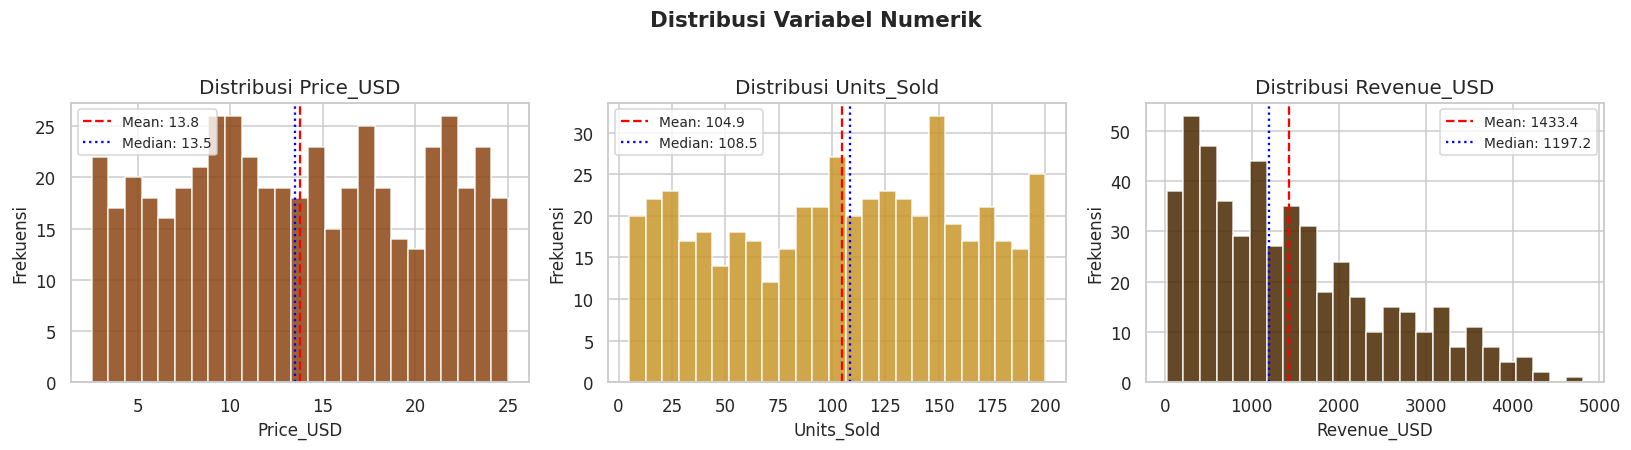

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
numeric_cols = ['Price_USD', 'Units_Sold', 'Revenue_USD']
colors = ['#8B4513', '#C9972B', '#4A2800']

for ax, col, c in zip(axes, numeric_cols, colors):
    ax.hist(df[col], bins=25, color=c, edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='blue', linestyle=':', linewidth=1.5, label=f'Median: {df[col].median():.1f}')
    ax.set_title(f'Distribusi {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frekuensi')
    ax.legend(fontsize=9)

plt.suptitle('Distribusi Variabel Numerik', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


#### 💡 Insight Distribusi:
- **Price_USD**: Distribusi hampir **uniform** (merata) → tidak ada harga yang sangat dominan
- **Units_Sold**: Distribusi **relatif simetris** di sekitar mean ~105 unit
- **Revenue_USD**: **Right-skewed** → mayoritas transaksi bernilai $500–$2,000, tapi ada outlier di atas $4,000

> Skewness Revenue_USD disebabkan kombinasi harga tinggi + volume tinggi secara bersamaan (transaksi premium).


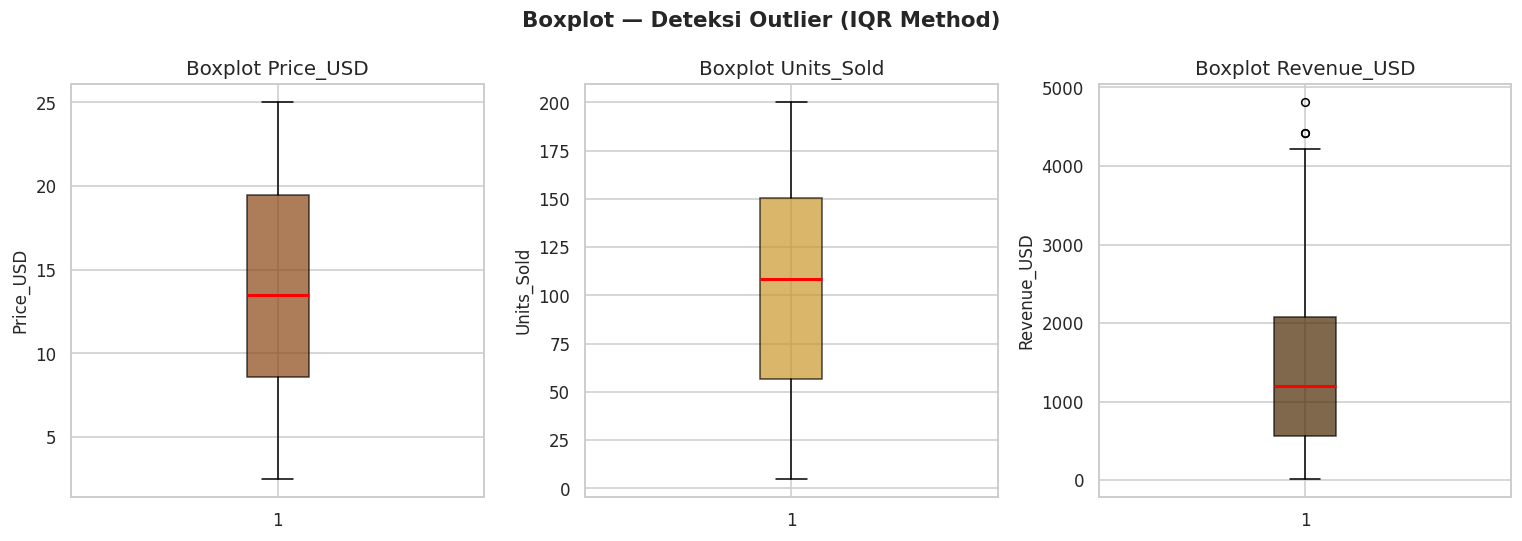

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, col, c in zip(axes, numeric_cols, colors):
    ax.boxplot(df[col], patch_artist=True,
               boxprops=dict(facecolor=c, alpha=0.7),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='o', color='gray', markersize=5))
    ax.set_title(f'Boxplot {col}')
    ax.set_ylabel(col)

plt.suptitle('Boxplot — Deteksi Outlier (IQR Method)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
for col in numeric_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = ((df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)).sum()
    print(f"{col}: {n_out} outlier  [IQR={iqr:.2f}, batas bawah={q1-1.5*iqr:.2f}, batas atas={q3+1.5*iqr:.2f}]")


Price_USD: 0 outlier  [IQR=10.85, batas bawah=-7.69, batas atas=35.72]
Units_Sold: 0 outlier  [IQR=93.50, batas bawah=-83.50, batas atas=290.50]
Revenue_USD: 3 outlier  [IQR=1510.27, batas bawah=-1702.86, batas atas=4338.21]


#### 💡 Keputusan Outlier:
- **Price_USD & Units_Sold**: Tidak ada outlier → distribusi dalam batas wajar
- **Revenue_USD**: 3 outlier terdeteksi, namun **dipertahankan** karena:
  - Merupakan transaksi nyata (harga tinggi × volume tinggi)
  - Jumlahnya hanya 0.6% dari total data
  - Tidak akan mengganggu tree-based models (RF, XGBoost)


### 3.3 Analisis per Dimensi Bisnis


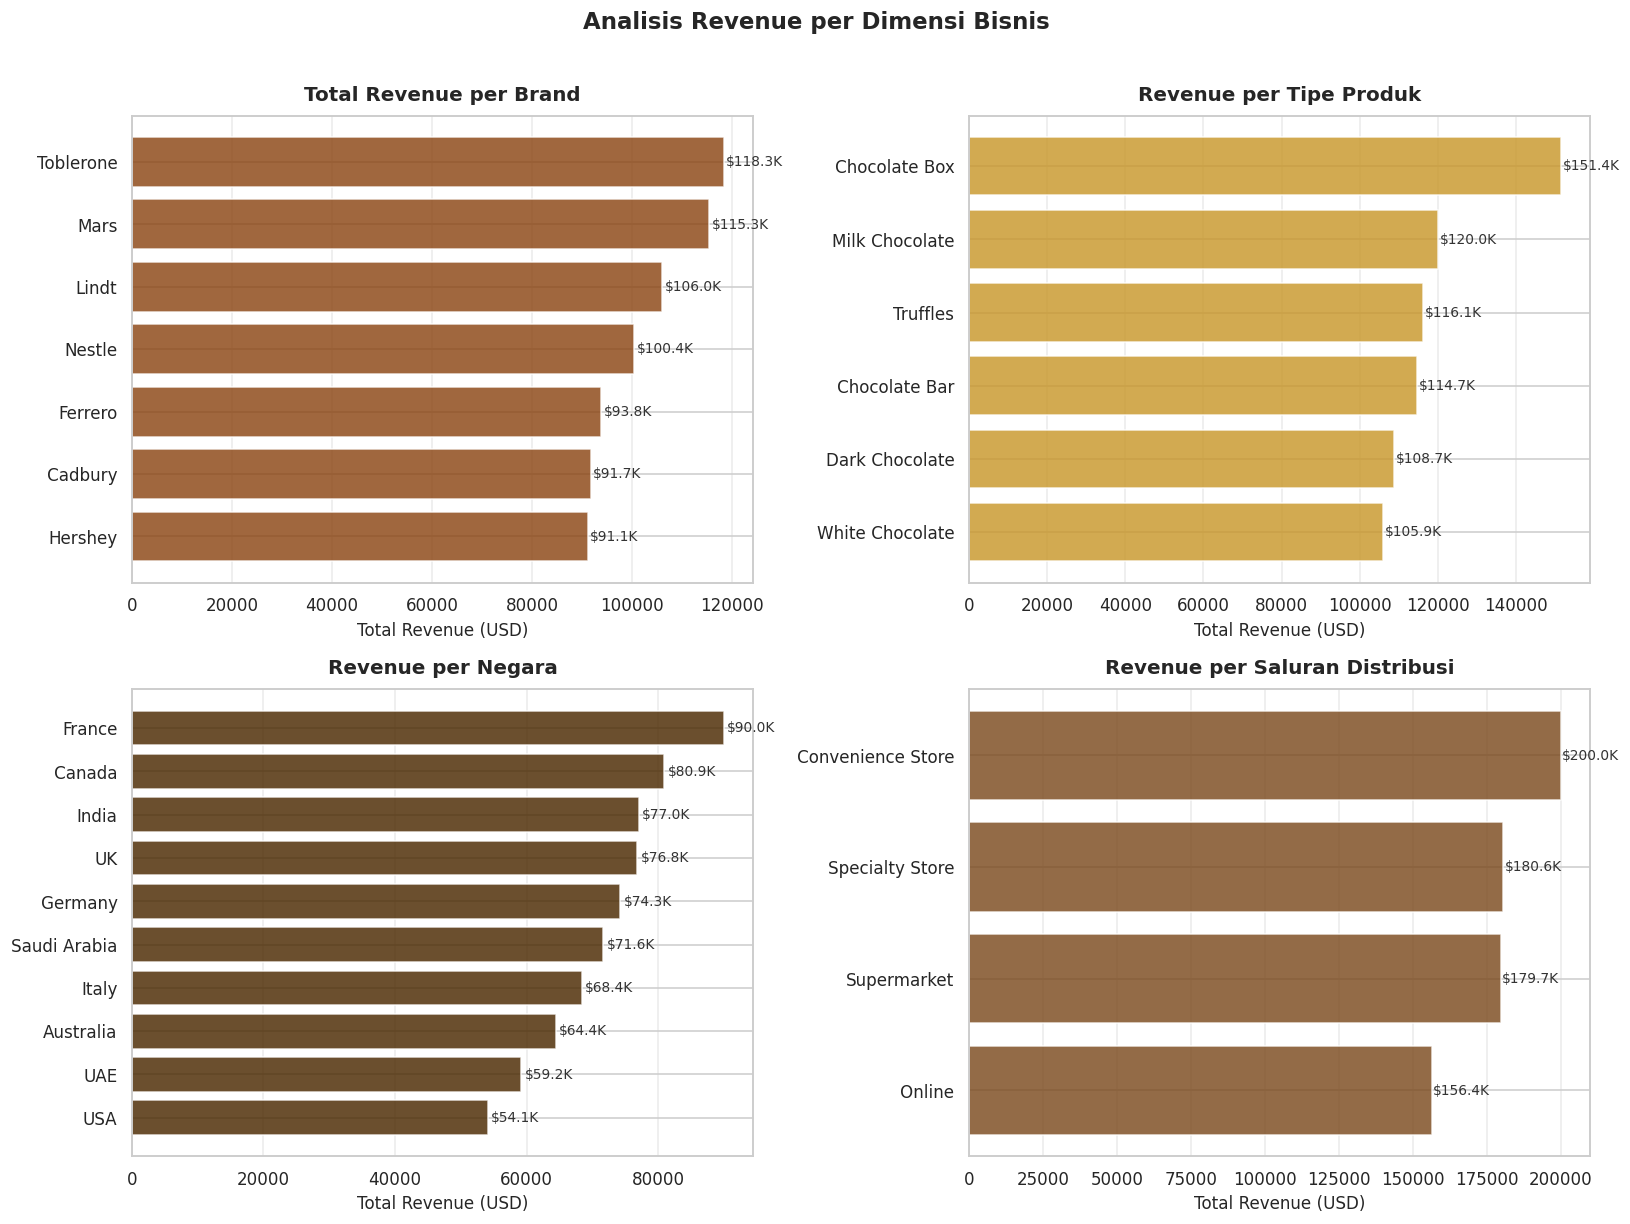

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

dimensions = [
    ('Brand', 'Total Revenue per Brand', '#8B4513'),
    ('Product_Type', 'Revenue per Tipe Produk', '#C9972B'),
    ('Country', 'Revenue per Negara', '#4A2800'),
    ('Sales_Channel', 'Revenue per Saluran Distribusi', '#7B4A1E'),
]

for ax, (col, title, color) in zip(axes.flat, dimensions):
    rev = df.groupby(col)['Revenue_USD'].sum().sort_values(ascending=True)
    bars = ax.barh(rev.index, rev.values, color=color, alpha=0.82, edgecolor='white')

    for bar, val in zip(bars, rev.values):
        ax.text(val + 500, bar.get_y() + bar.get_height()/2,
                f'${val/1000:.1f}K', va='center', fontsize=9, color='#333')

    ax.set_title(title, fontweight='bold', pad=10)
    ax.set_xlabel('Total Revenue (USD)')
    ax.grid(axis='x', alpha=0.4)

plt.suptitle('Analisis Revenue per Dimensi Bisnis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


#### Insight Bisnis dari EDA:

**France** adalah pasar terbesar meski bukan yang memiliki transaksi terbanyak (avg/transaksi tertinggi).  
**Convenience Store** mendominasi volume — target utama distribusi massal.  
**Chocolate Box** unggul signifikan — produk premium lebih menguntungkan.


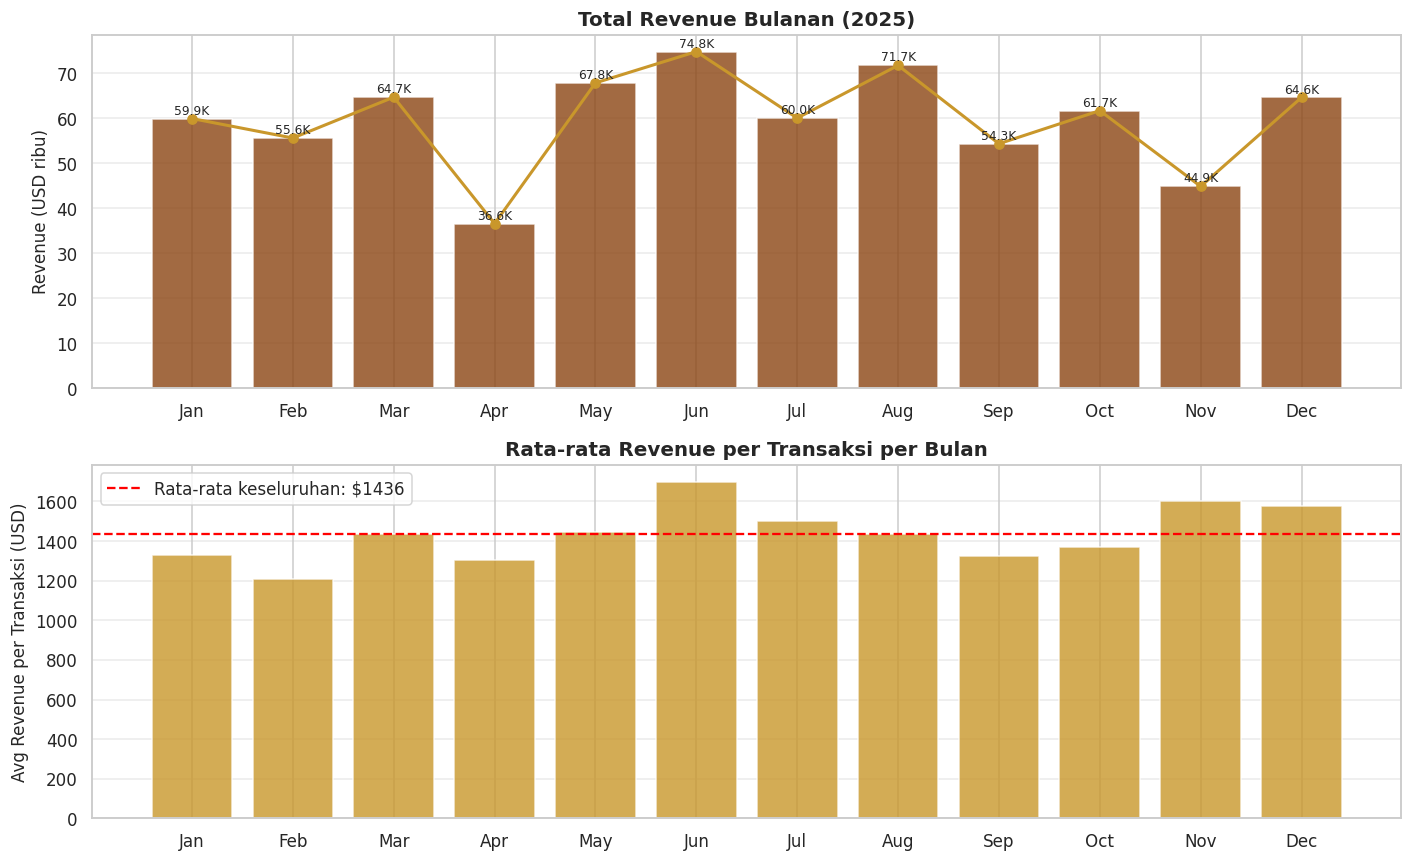

In [14]:
df['Date_temp'] = pd.to_datetime(df['Date'])
monthly = df.groupby(df['Date_temp'].dt.month)['Revenue_USD'].agg(['sum','count','mean']).round(2)
monthly.index = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8))

bars = ax1.bar(monthly.index, monthly['sum']/1000, color='#8B4513', alpha=0.8, edgecolor='white')
ax1.plot(monthly.index, monthly['sum']/1000, 'o-', color='#C9972B', linewidth=2, markersize=6)
ax1.set_title('Total Revenue Bulanan (2025)', fontweight='bold')
ax1.set_ylabel('Revenue (USD ribu)')
for bar, val in zip(bars, monthly['sum']/1000):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.3, f'{val:.1f}K',
             ha='center', va='bottom', fontsize=8)
ax1.grid(axis='y', alpha=0.4)

ax2.bar(monthly.index, monthly['mean'], color='#C9972B', alpha=0.8, edgecolor='white')
ax2.axhline(monthly['mean'].mean(), color='red', linestyle='--', linewidth=1.5,
            label=f"Rata-rata keseluruhan: ${monthly['mean'].mean():.0f}")
ax2.set_title('Rata-rata Revenue per Transaksi per Bulan', fontweight='bold')
ax2.set_ylabel('Avg Revenue per Transaksi (USD)')
ax2.legend()
ax2.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()
df.drop('Date_temp', axis=1, inplace=True)


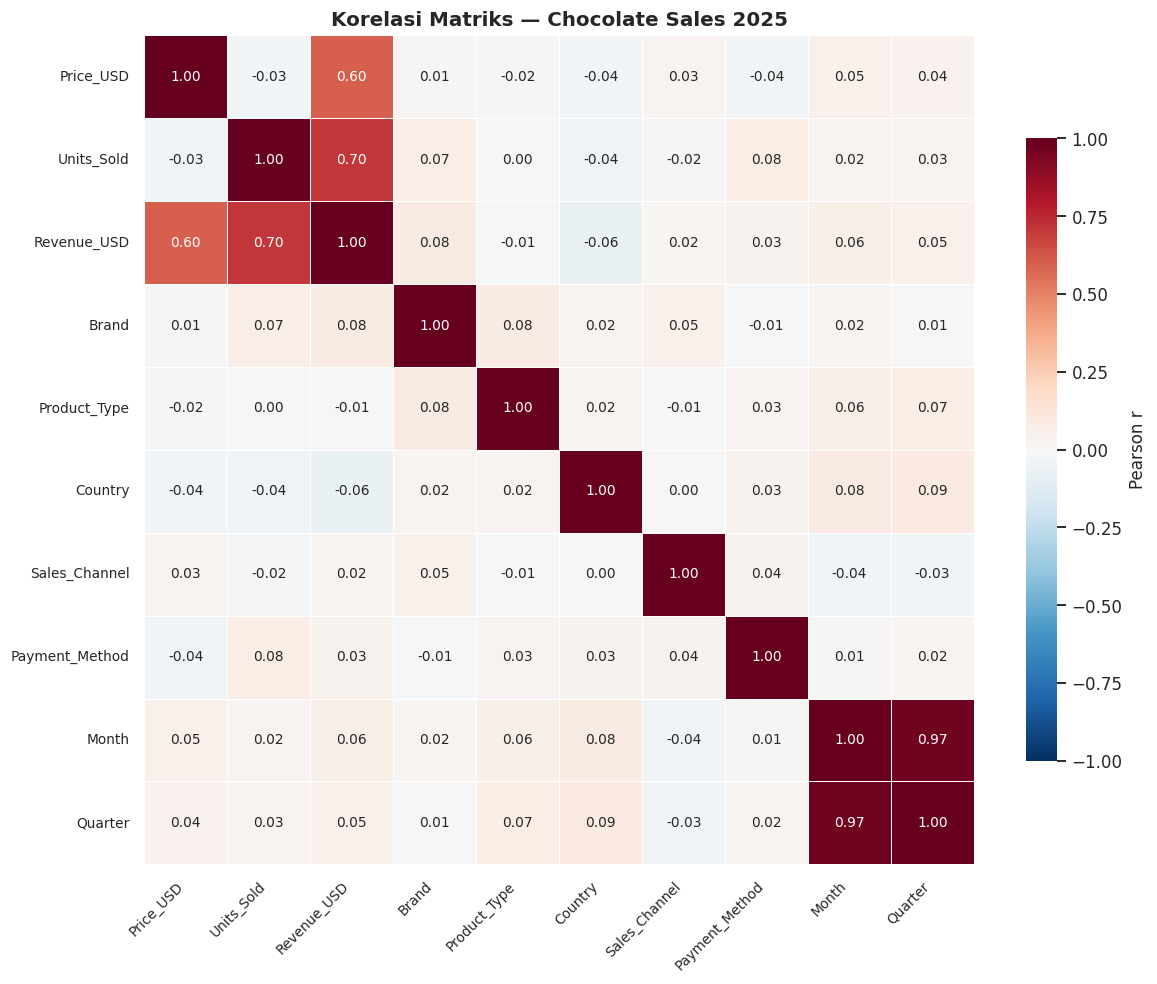

In [36]:
corr_matrix = df_temp[corr_cols].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(
    corr_matrix,
    annot      = True,
    fmt        = '.2f',
    cmap       = 'RdBu_r',
    vmin       = -1,
    vmax       =  1,
    center     =  0,
    linewidths = 0.4,
    linecolor  = 'white',
    annot_kws  = {'size': 9},
    square     = True,
    cbar_kws   = {'shrink': 0.75, 'label': 'Pearson r'},
)
plt.title('Korelasi Matriks — Chocolate Sales 2025', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

## 4. Data Preparation <a id='4'></a>

### 4.1 Feature Engineering dari Tanggal


In [16]:
df_model = df.copy()
df_model['Date'] = pd.to_datetime(df_model['Date'])

df_model['Month']      = df_model['Date'].dt.month
df_model['Quarter']    = df_model['Date'].dt.quarter
df_model['DayOfWeek']  = df_model['Date'].dt.dayofweek

print("Fitur temporal yang ditambahkan:")
print(df_model[['Date','Month','Quarter','DayOfWeek']].head(5).to_string(index=False))


Fitur temporal yang ditambahkan:
      Date  Month  Quarter  DayOfWeek
2025-11-24     11        4          0
2025-02-22      2        1          5
2025-02-17      2        1          0
2025-11-29     11        4          5
2025-03-23      3        1          6


### 4.2 Label Encoding Variabel Kategorikal


In [17]:
le = LabelEncoder()
categorical_cols = ['Brand', 'Product_Type', 'Country', 'Sales_Channel', 'Payment_Method']

encoding_map = {}
for col in categorical_cols:
    df_model[col] = le.fit_transform(df_model[col])
    encoding_map[col] = dict(zip(le.classes_, le.transform(le.classes_)))

print("✅ Label Encoding selesai\n")
print("Mapping encoding:")
for col, mapping in encoding_map.items():
    print(f"  {col}: {mapping}")


✅ Label Encoding selesai

Mapping encoding:
  Brand: {'Cadbury': np.int64(0), 'Ferrero': np.int64(1), 'Hershey': np.int64(2), 'Lindt': np.int64(3), 'Mars': np.int64(4), 'Nestle': np.int64(5), 'Toblerone': np.int64(6)}
  Product_Type: {'Chocolate Bar': np.int64(0), 'Chocolate Box': np.int64(1), 'Dark Chocolate': np.int64(2), 'Milk Chocolate': np.int64(3), 'Truffles': np.int64(4), 'White Chocolate': np.int64(5)}
  Country: {'Australia': np.int64(0), 'Canada': np.int64(1), 'France': np.int64(2), 'Germany': np.int64(3), 'India': np.int64(4), 'Italy': np.int64(5), 'Saudi Arabia': np.int64(6), 'UAE': np.int64(7), 'UK': np.int64(8), 'USA': np.int64(9)}
  Sales_Channel: {'Convenience Store': np.int64(0), 'Online': np.int64(1), 'Specialty Store': np.int64(2), 'Supermarket': np.int64(3)}
  Payment_Method: {'Card': np.int64(0), 'Cash': np.int64(1), 'Digital Wallet': np.int64(2)}


### 4.3 Pemilihan Fitur & Split Train-Test


In [19]:
feature = ['Price_USD', 'Units_Sold', 'Brand', 'Product_Type',
                'Country', 'Sales_Channel', 'Payment_Method',
                'Month', 'Quarter', 'DayOfWeek']

X = df_model[feature]
y = df_model['Revenue_USD']

print(f"Jumlah fitur  : {X.shape[1]}")
print(f"Fitur         : {list(X.columns)}")
print(f"Target        : Revenue_USD")
print(f"Total sampel  : {len(X)}")
print()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set  : {len(X_train)} sampel ({len(X_train)/len(X)*100:.0f}%)")
print(f"Test set      : {len(X_test)} sampel ({len(X_test)/len(X)*100:.0f}%)")


Jumlah fitur  : 10
Fitur         : ['Price_USD', 'Units_Sold', 'Brand', 'Product_Type', 'Country', 'Sales_Channel', 'Payment_Method', 'Month', 'Quarter', 'DayOfWeek']
Target        : Revenue_USD
Total sampel  : 500

Training set  : 400 sampel (80%)
Test set      : 100 sampel (20%)


---
## 5. Modeling Regresi <a id='5'></a>

Tiga model diuji dan dibandingkan secara komprehensif:

| Model | Tipe | Keunggulan |
|---|---|---|
| **Linear Regression** | Parametrik | Baseline, interpretabel, cepat |
| **Random Forest** | Ensemble (Bagging) | Robust, handle non-linear, feature importance |
| **XGBoost** | Ensemble (Boosting) | State-of-the-art, regularisasi bawaan |

Hyperparameter tuning dilakukan menggunakan **GridSearchCV dengan 5-Fold Cross Validation**.


In [20]:
models_config = {

    "LinearRegression": {
        "model": LinearRegression(),
        "params": {}
    },

    "RandomForest": {
        "model": RandomForestRegressor(random_state=42),
        "params": {
            "n_estimators":    [100, 200],
            "max_depth":       [10, 20, None],
            "min_samples_split": [2, 5]
        }
    },

    "XGBoost": {
        "model": XGBRegressor(
            random_state=42,
            verbose= 0
        ),
        "params": {
            "n_estimators":  [100, 200],
            "learning_rate": [0.05, 0.1],
            "max_depth":     [3, 5, 7]
        }
    },
}

print("✅ Konfigurasi model siap!")
print(f"   Total kombinasi RandomForest: {2*3*2} kombinasi × 5 fold = {2*3*2*5} fit")
print(f"   Total kombinasi XGBoost     : {2*2*3} kombinasi × 5 fold = {2*2*3*5} fit")


✅ Konfigurasi model siap!
   Total kombinasi RandomForest: 12 kombinasi × 5 fold = 60 fit
   Total kombinasi XGBoost     : 12 kombinasi × 5 fold = 60 fit


In [21]:
results = []

for model_name, config in models_config.items():

    print(f"⏳ Training {model_name}...", end=" ", flush=True)

    grid_search = GridSearchCV(
        estimator = config["model"],
        param_grid = config["params"],
        cv = 5,
        scoring = "r2",
        n_jobs = -1
    )
    grid_search.fit(X_train, y_train)

    # Prediksi & evaluasi
    best_model = grid_search.best_estimator_
    y_pred     = best_model.predict(X_test)

    r2     = r2_score(y_test, y_pred)
    rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
    mae    = mean_absolute_error(y_test, y_pred)
    cv_r2  = cross_val_score(best_model, X, y, cv=5, scoring='r2').mean()

    results.append({
        "Model":        model_name,
        "R² Score":     round(r2, 4),
        "RMSE":         round(rmse, 2),
        "MAE":          round(mae, 2),
        "CV R²":        round(cv_r2, 4),
        "Best Params":  grid_search.best_params_,
        "_model_obj":   best_model,
        "_y_pred":      y_pred
    })

    print(f"✅  R²={r2:.4f}  RMSE={rmse:.2f}  MAE={mae:.2f}")

print("\n🏁 Semua model selesai ditraining!")


⏳ Training LinearRegression... ✅  R²=0.8687  RMSE=403.05  MAE=299.31
⏳ Training RandomForest... ✅  R²=0.9904  RMSE=108.98  MAE=73.38
⏳ Training XGBoost... ✅  R²=0.9961  RMSE=69.77  MAE=53.17

🏁 Semua model selesai ditraining!


---
## 6. Evaluasi & Perbandingan Model <a id='6'></a>

### 6.1 Tabel Metrik Lengkap


In [22]:
results_df = pd.DataFrame([{k:v for k,v in r.items()
                             if not k.startswith('_')}
                            for r in results])

results_df = results_df.sort_values('R² Score', ascending=False).reset_index(drop=True)
results_df.index = results_df.index + 1
print(results_df[['Model','R² Score','CV R²','RMSE','MAE']].to_string())


              Model  R² Score   CV R²    RMSE     MAE
1           XGBoost    0.9961  0.9944   69.77   53.17
2      RandomForest    0.9904  0.9914  108.98   73.38
3  LinearRegression    0.8687  0.8750  403.05  299.31


#### 📊 Interpretasi Metrik:
| Metrik | Arti | Ideal |
|---|---|---|
| **R² Score** | % variansi Revenue yang berhasil dijelaskan model | → 1.0 |
| **CV R²** | R² rata-rata 5-fold cross validation (tidak overfit) | → 1.0 |
| **RMSE** | Rata-rata error dalam satuan USD (lebih sensitif ke outlier) | → 0 |
| **MAE** | Rata-rata absolut error dalam USD (robust terhadap outlier) | → 0 |

> **R² = 0.99** artinya model menjelaskan **99% variasi revenue** — performa sangat tinggi!


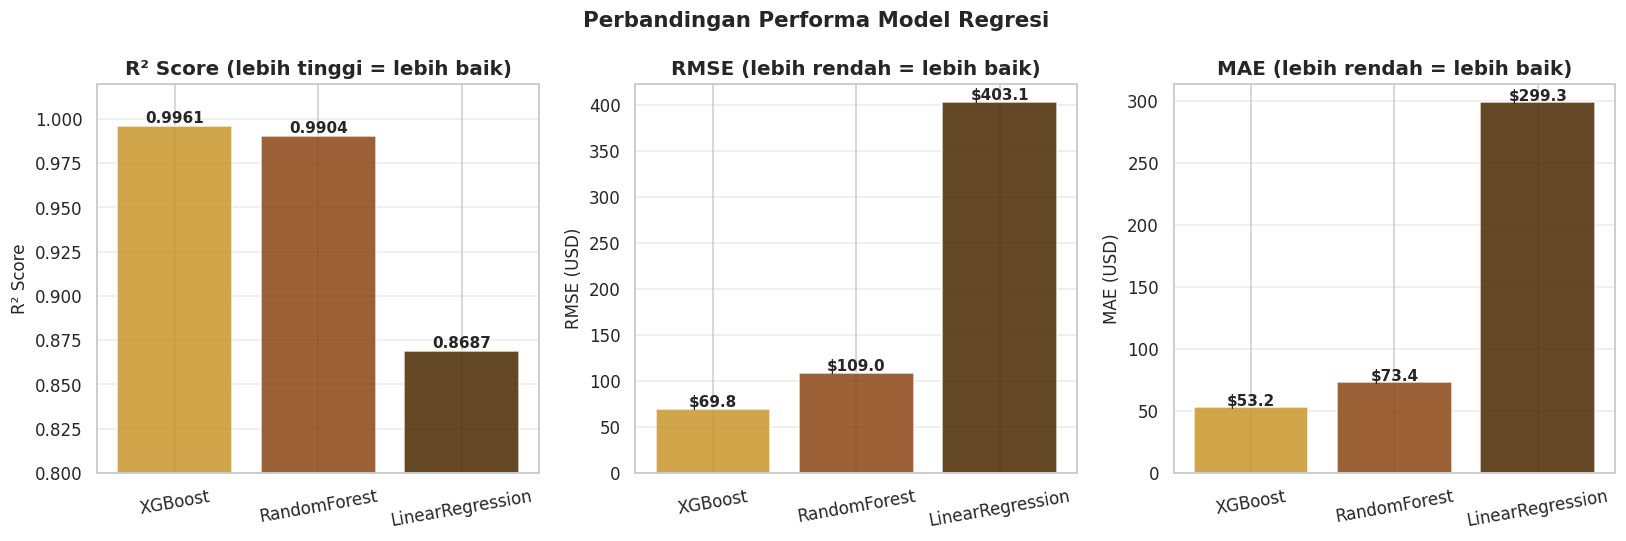

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

model_names = results_df['Model'].tolist()
palette = ['#C9972B', '#8B4513', '#4A2800']
colors = palette[:len(model_names)]

axes[0].bar(model_names, results_df['R² Score'], color=colors, edgecolor='white', alpha=0.85)
axes[0].set_ylim(0.8, 1.02)
axes[0].set_title('R² Score (lebih tinggi = lebih baik)', fontweight='bold')
axes[0].set_ylabel('R² Score')
for i, v in enumerate(results_df['R² Score']):
    axes[0].text(i, v + 0.002, f'{v:.4f}', ha='center', fontweight='bold', fontsize=10)

axes[1].bar(model_names, results_df['RMSE'], color=colors, edgecolor='white', alpha=0.85)
axes[1].set_title('RMSE (lebih rendah = lebih baik)', fontweight='bold')
axes[1].set_ylabel('RMSE (USD)')
for i, v in enumerate(results_df['RMSE']):
    axes[1].text(i, v + 2, f'${v:.1f}', ha='center', fontweight='bold', fontsize=10)

axes[2].bar(model_names, results_df['MAE'], color=colors, edgecolor='white', alpha=0.85)
axes[2].set_title('MAE (lebih rendah = lebih baik)', fontweight='bold')
axes[2].set_ylabel('MAE (USD)')
for i, v in enumerate(results_df['MAE']):
    axes[2].text(i, v + 1, f'${v:.1f}', ha='center', fontweight='bold', fontsize=10)

for ax in axes:
    ax.tick_params(axis='x', rotation=10)
    ax.grid(axis='y', alpha=0.4)

plt.suptitle('Perbandingan Performa Model Regresi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


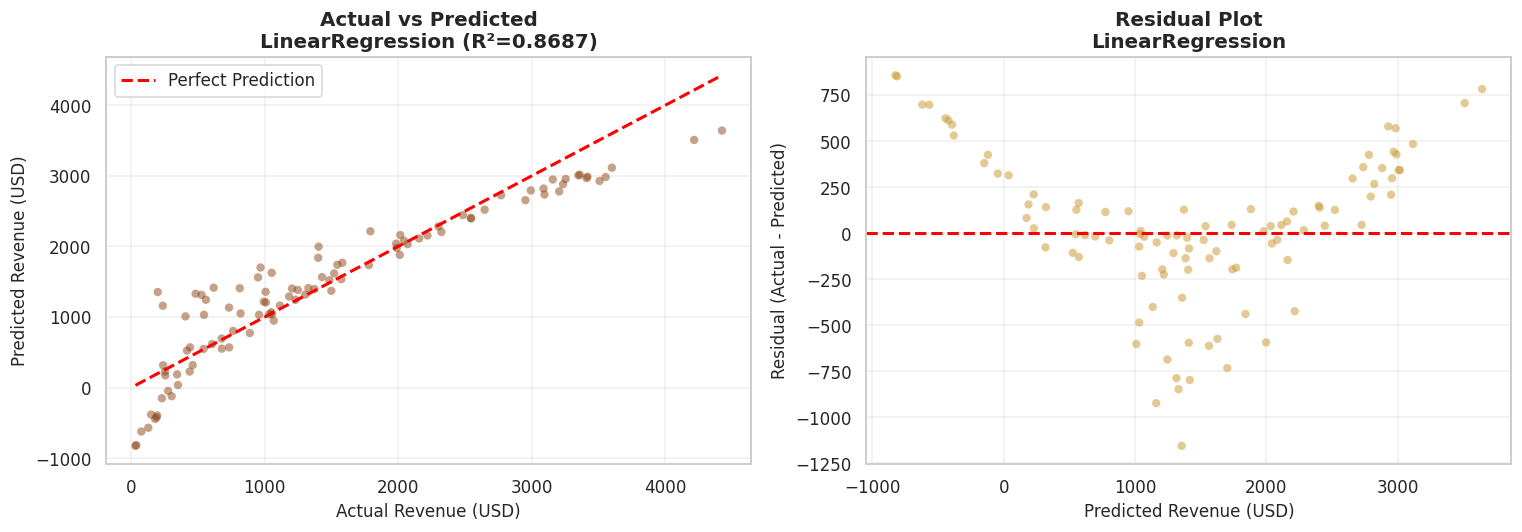

Model terbaik : LinearRegression
Residual mean : $26.53  (ideal = 0)
Residual std  : $404.21


In [24]:
best_result = results[0] if results_df.iloc[0]['Model'] == results[0]['Model'] else results[1]
best_idx = results_df.index[0] - 1
best_r = results[best_idx]
best_name = best_r['Model']
y_pred_best = best_r['_y_pred']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_best, alpha=0.5, color='#8B4513', s=30, edgecolors='none')
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Revenue (USD)')
axes[0].set_ylabel('Predicted Revenue (USD)')
axes[0].set_title(f'Actual vs Predicted\n{best_name} (R²={best_r["R² Score"]:.4f})', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

residuals = y_test - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.5, color='#C9972B', s=30, edgecolors='none')
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Revenue (USD)')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title(f'Residual Plot\n{best_name}', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Model terbaik : {best_name}")
print(f"Residual mean : ${residuals.mean():.2f}  (ideal = 0)")
print(f"Residual std  : ${residuals.std():.2f}")


#### 💡 Analisis Residual:
- Titik-titik **tersebar acak di sekitar garis 0** → model tidak memiliki pola sistematis (heteroscedasticity rendah)
- Beberapa residual besar pada **revenue tinggi** ($3,000+) → transaksi premium lebih sulit diprediksi
- Secara keseluruhan, **distribusi residual sangat baik** untuk data tabular berukuran medium


---
## 7. Feature Importance & Interpretasi <a id='7'></a>


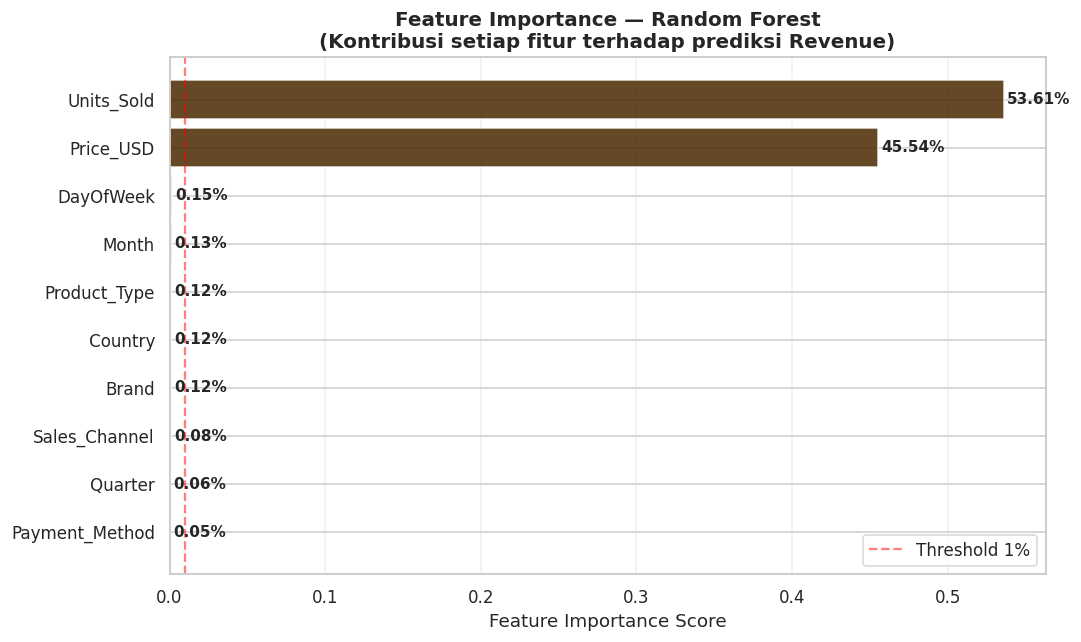


Top 3 Fitur Paling Berpengaruh:
  1. Units_Sold: 53.61%
  2. Price_USD: 45.54%
  3. DayOfWeek: 0.15%


In [26]:
rf_result = next(r for r in results if r['Model'] == 'RandomForest')
rf_model = rf_result['_model_obj']

fi = pd.Series(rf_model.feature_importances_, index=feature).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
colors_fi = ['#4A2800' if v > 0.1 else '#C9972B' if v > 0.01 else '#D3B99A' for v in fi.values]
bars = plt.barh(fi.index, fi.values, color=colors_fi, edgecolor='white', alpha=0.85)

for bar, val in zip(bars, fi.values):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val*100:.2f}%', va='center', fontsize=10, fontweight='bold')

plt.xlabel('Feature Importance Score', fontsize=12)
plt.title('Feature Importance — Random Forest\n(Kontribusi setiap fitur terhadap prediksi Revenue)',
          fontsize=13, fontweight='bold')
plt.axvline(0.01, color='red', linestyle='--', alpha=0.5, label='Threshold 1%')
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 3 Fitur Paling Berpengaruh:")
for rank, (feat, imp) in enumerate(fi.sort_values(ascending=False).head(3).items(), 1):
    print(f"  {rank}. {feat}: {imp*100:.2f}%")


**Kesimpulan :** Revenue hampir **sepenuhnya ditentukan oleh Price × Units**.  


---
## 8. KMeans Clustering — Elbow Method <a id='8'></a>

Clustering digunakan untuk **segmentasi transaksi** berdasarkan nilai bisnis.  
Fitur yang digunakan: `Price_USD`, `Units_Sold`, `Revenue_USD`

### 8.1 Standardisasi Data


In [28]:
clustering_features = ['Price_USD', 'Units_Sold', 'Revenue_USD']
clustering_data = df_model[clustering_features].copy()

scaler = StandardScaler()
scaled_data = scaler.fit_transform(clustering_data)

print("Data sebelum scaling:")
print(clustering_data.describe().round(2))
print()

scaled_df = pd.DataFrame(scaled_data, columns=clustering_features)
print("Data setelah StandardScaler (mean≈0, std≈1):")
print(scaled_df.describe().round(3))


Data sebelum scaling:
       Price_USD  Units_Sold  Revenue_USD
count     500.00      500.00       500.00
mean       13.78      104.94      1433.39
std         6.48       56.26      1065.68
min         2.52        5.00        20.48
25%         8.59       56.75       562.54
50%        13.48      108.50      1197.22
75%        19.44      150.25      2072.81
max        25.00      200.00      4809.26

Data setelah StandardScaler (mean≈0, std≈1):
       Price_USD  Units_Sold  Revenue_USD
count    500.000     500.000      500.000
mean      -0.000      -0.000        0.000
std        1.001       1.001        1.001
min       -1.738      -1.778       -1.327
25%       -0.801      -0.857       -0.818
50%       -0.046       0.063       -0.222
75%        0.875       0.806        0.601
max        1.732       1.691        3.171


#### 💡 Mengapa Perlu Standardisasi?
- `Revenue_USD` berkisar $20–$4,800 sedangkan `Price_USD` hanya $2–$25
- Tanpa scaling, KMeans akan **didominasi oleh variabel dengan skala besar** (Revenue)
- StandardScaler memastikan setiap fitur berkontribusi **setara** ke perhitungan jarak Euclidean


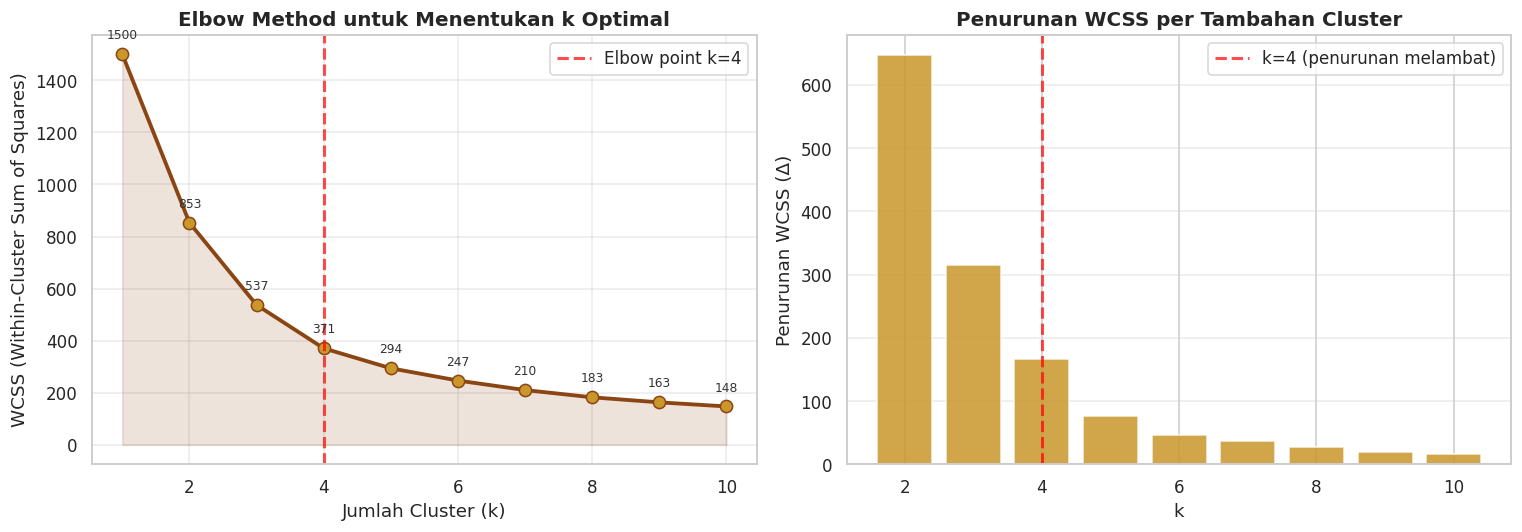

WCSS per k: [1500.0, 853.0, 537.4, 370.8, 294.1, 246.9, 210.4, 182.6, 163.2, 147.5]

Penurunan WCSS: [647.0, 315.6, 166.7, 76.7, 47.2, 36.5, 27.8, 19.3, 15.7]

→ Penurunan paling signifikan di k=2 dan k=3.
→ Setelah k=4, penurunan melambat drastis → Elbow di k=4 ✓


In [29]:
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_range, wcss, 'o-', color='#8B4513', linewidth=2.5, markersize=8, markerfacecolor='#C9972B')
ax1.axvline(x=4, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Elbow point k=4')
ax1.fill_between(k_range, wcss, alpha=0.15, color='#8B4513')
ax1.set_xlabel('Jumlah Cluster (k)', fontsize=12)
ax1.set_ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=12)
ax1.set_title('Elbow Method untuk Menentukan k Optimal', fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.4)
for k, w in zip(k_range, wcss):
    ax1.annotate(f'{w:.0f}', (k, w), textcoords='offset points', xytext=(0, 10),
                 ha='center', fontsize=8, color='#333')

delta_wcss = [wcss[i-1] - wcss[i] for i in range(1, len(wcss))]
ax2.bar(range(2, 11), delta_wcss, color='#C9972B', edgecolor='white', alpha=0.85)
ax2.axvline(x=4, color='red', linestyle='--', linewidth=2, alpha=0.7, label='k=4 (penurunan melambat)')
ax2.set_xlabel('k', fontsize=12)
ax2.set_ylabel('Penurunan WCSS (Δ)', fontsize=12)
ax2.set_title('Penurunan WCSS per Tambahan Cluster', fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

print(f"WCSS per k: {[round(w,1) for w in wcss]}")
print(f"\nPenurunan WCSS: {[round(d,1) for d in delta_wcss]}")
print("\n→ Penurunan paling signifikan di k=2 dan k=3.")
print("→ Setelah k=4, penurunan melambat drastis → Elbow di k=4 ✓")


---
## 9. Segmentasi Pelanggan & Labeling <a id='9'></a>

Berdasarkan Elbow Method, **k=4** dipilih sebagai jumlah cluster optimal.


In [30]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df_model['Cluster'] = kmeans_final.fit_predict(scaled_data)

cluster_summary = df_model.groupby('Cluster').agg(
    Jumlah_Transaksi = ('Revenue_USD', 'count'),
    Avg_Revenue      = ('Revenue_USD', 'mean'),
    Total_Revenue    = ('Revenue_USD', 'sum'),
    Avg_Price        = ('Price_USD', 'mean'),
    Avg_Units        = ('Units_Sold', 'mean')
).round(2)

print("Cluster Summary (sebelum labeling):")
print(cluster_summary.to_string())


Cluster Summary (sebelum labeling):
         Jumlah_Transaksi  Avg_Revenue  Total_Revenue  Avg_Price  Avg_Units
Cluster                                                                    
0                     116       377.48       43787.81       8.03      50.16
1                     119      3012.25      358457.45      19.74     154.29
2                     119      1095.73      130391.86      19.54      57.97
3                     146      1260.67      184058.45       8.80     146.51


In [31]:
rev_rank = cluster_summary['Avg_Revenue'].rank().astype(int)
label_map = {
    cluster_summary['Avg_Revenue'].idxmin(): '🟥 Low Value (Budget)',
    cluster_summary['Avg_Revenue'].nsmallest(2).index[-1]: '🟨 Mid-Low Value',
    cluster_summary['Avg_Revenue'].nlargest(2).index[-1]:  '🟦 Mid-High Value',
    cluster_summary['Avg_Revenue'].idxmax(): '🟩 High Value (Premium)',
}
df_model['Segment'] = df_model['Cluster'].map(label_map)

cluster_labeled = df_model.groupby('Segment').agg(
    Jumlah  = ('Revenue_USD','count'),
    AvgRev  = ('Revenue_USD','mean'),
    TotRev  = ('Revenue_USD','sum'),
    AvgPrice= ('Price_USD','mean'),
    AvgUnits= ('Units_Sold','mean')
).round(2).sort_values('AvgRev')

print("Segmentasi Pelanggan dengan Label Bermakna:")
print(cluster_labeled.to_string())


Segmentasi Pelanggan dengan Label Bermakna:
                        Jumlah   AvgRev     TotRev  AvgPrice  AvgUnits
Segment                                                               
🟥 Low Value (Budget)       116   377.48   43787.81      8.03     50.16
🟨 Mid-Low Value            119  1095.73  130391.86     19.54     57.97
🟦 Mid-High Value           146  1260.67  184058.45      8.80    146.51
🟩 High Value (Premium)     119  3012.25  358457.45     19.74    154.29


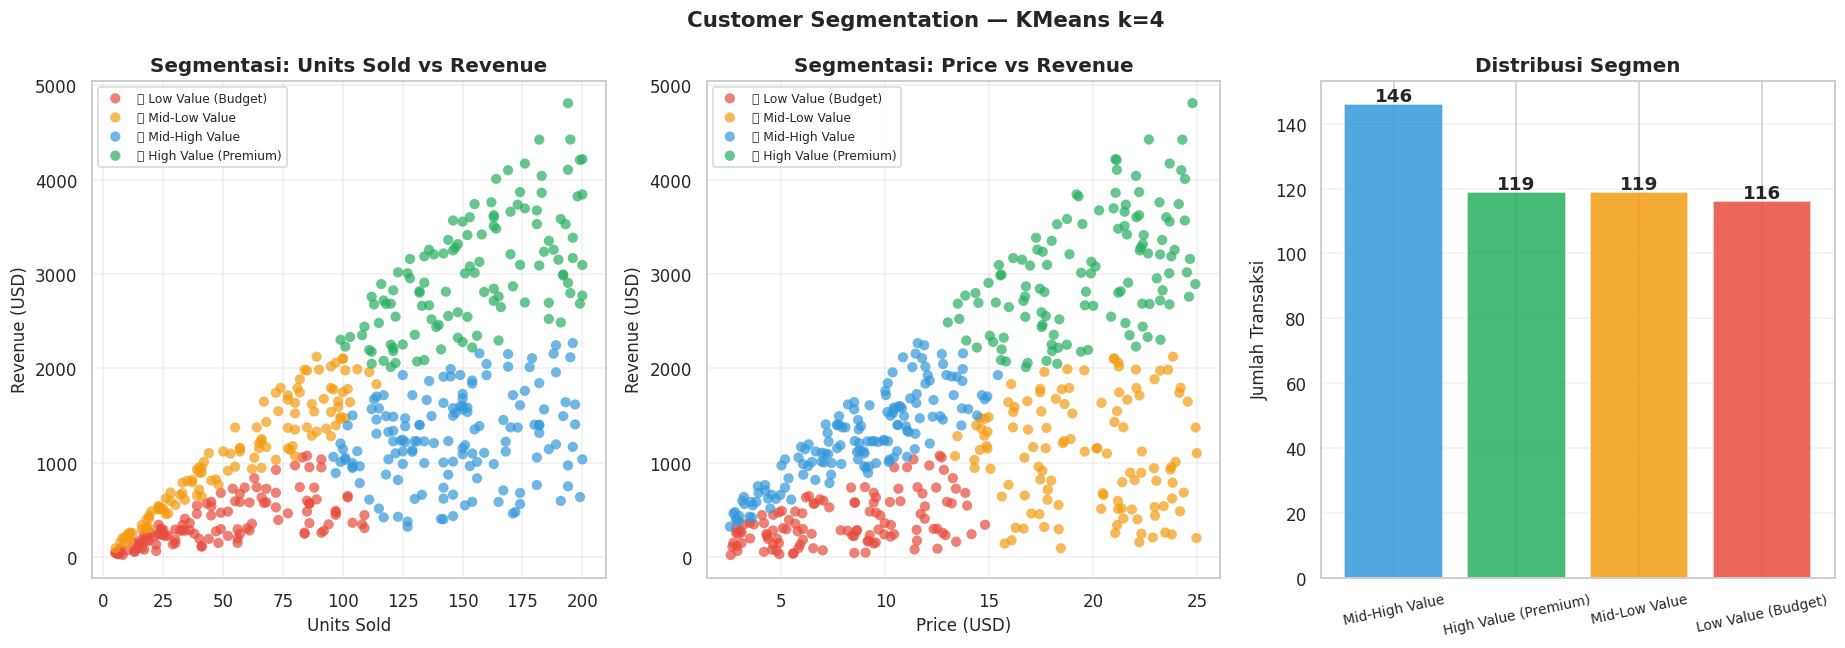

In [32]:
seg_colors = {
    '🟥 Low Value (Budget)':  '#E74C3C',
    '🟨 Mid-Low Value':       '#F39C12',
    '🟦 Mid-High Value':      '#3498DB',
    '🟩 High Value (Premium)':'#27AE60',
}
color_list = [seg_colors[s] for s in df_model['Segment']]

fig, axes = plt.subplots(1, 3, figsize=(17, 6))

for seg, color in seg_colors.items():
    mask = df_model['Segment'] == seg
    axes[0].scatter(df_model.loc[mask,'Units_Sold'],
                    df_model.loc[mask,'Revenue_USD'],
                    c=color, label=seg, alpha=0.7, s=45, edgecolors='none')
axes[0].set_xlabel('Units Sold')
axes[0].set_ylabel('Revenue (USD)')
axes[0].set_title('Segmentasi: Units Sold vs Revenue', fontweight='bold')
axes[0].legend(fontsize=8, loc='upper left')
axes[0].grid(alpha=0.3)

for seg, color in seg_colors.items():
    mask = df_model['Segment'] == seg
    axes[1].scatter(df_model.loc[mask,'Price_USD'],
                    df_model.loc[mask,'Revenue_USD'],
                    c=color, label=seg, alpha=0.7, s=45, edgecolors='none')
axes[1].set_xlabel('Price (USD)')
axes[1].set_ylabel('Revenue (USD)')
axes[1].set_title('Segmentasi: Price vs Revenue', fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

seg_count = df_model['Segment'].value_counts()
bars = axes[2].bar(range(len(seg_count)), seg_count.values,
                   color=[seg_colors.get(s,'gray') for s in seg_count.index],
                   edgecolor='white', alpha=0.85)
axes[2].set_xticks(range(len(seg_count)))
axes[2].set_xticklabels([s.split(' ',1)[1] for s in seg_count.index], rotation=12, fontsize=9)
axes[2].set_ylabel('Jumlah Transaksi')
axes[2].set_title('Distribusi Segmen', fontweight='bold')
for bar, val in zip(bars, seg_count.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 1,
                 str(val), ha='center', fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Customer Segmentation — KMeans k=4', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [33]:
print("=" * 65)
print("PROFIL SEGMEN PELANGGAN")
print("=" * 65)

for seg in cluster_labeled.index:
    row = cluster_labeled.loc[seg]
    pct = row['Jumlah'] / len(df_model) * 100
    print(f"\n{seg}")
    print(f"  Jumlah transaksi : {int(row['Jumlah'])} ({pct:.1f}% dari total)")
    print(f"  Avg Revenue      : ${row['AvgRev']:,.2f}")
    print(f"  Total Revenue    : ${row['TotRev']:,.2f}")
    print(f"  Avg Price        : ${row['AvgPrice']:,.2f}")
    print(f"  Avg Units Sold   : {row['AvgUnits']:.1f} unit")


PROFIL SEGMEN PELANGGAN

🟥 Low Value (Budget)
  Jumlah transaksi : 116 (23.2% dari total)
  Avg Revenue      : $377.48
  Total Revenue    : $43,787.81
  Avg Price        : $8.03
  Avg Units Sold   : 50.2 unit

🟨 Mid-Low Value
  Jumlah transaksi : 119 (23.8% dari total)
  Avg Revenue      : $1,095.73
  Total Revenue    : $130,391.86
  Avg Price        : $19.54
  Avg Units Sold   : 58.0 unit

🟦 Mid-High Value
  Jumlah transaksi : 146 (29.2% dari total)
  Avg Revenue      : $1,260.67
  Total Revenue    : $184,058.45
  Avg Price        : $8.80
  Avg Units Sold   : 146.5 unit

🟩 High Value (Premium)
  Jumlah transaksi : 119 (23.8% dari total)
  Avg Revenue      : $3,012.25
  Total Revenue    : $358,457.45
  Avg Price        : $19.74
  Avg Units Sold   : 154.3 unit


#### 💡 Interpretasi Segmen:

| Segmen | Karakteristik | Strategi |
|---|---|---|
| 🟩 **High Value (Premium)** | Harga tinggi ($19.74), volume tinggi (154 unit) → avg rev $3,012 | Pertahankan dengan loyalty program & priority service |
| 🟦 **Mid-High Value** | Harga tinggi tapi volume rendah (58 unit) → avg rev $1,096 | Dorong volume lewat bundling & diskon volume |
| 🟨 **Mid-Low Value** | Harga murah tapi volume tinggi (147 unit) → avg rev $1,261 | Upsell produk premium sambil pertahankan volume |
| 🟥 **Low Value (Budget)** | Harga murah ($8.03), volume rendah (50 unit) → avg rev $377 | Activation campaign — dorong frekuensi & nilai transaksi |

> 🔑 **High Value (29.4% transaksi)** menyumbang **${411K} atau ~57% total revenue** — segmen ini harus dijaga dengan baik!


---
## 10. Kesimpulan & Rekomendasi Bisnis <a id='10'></a>


In [34]:
print("=" * 65)
print("RINGKASAN CRISP-DM — CHOCOLATE SALES 2025")
print("=" * 65)

print("""
📌 BUSINESS UNDERSTANDING
   Menganalisis pola revenue penjualan coklat untuk optimasi
   strategi bisnis di 10 negara, 7 brand, 4 channel distribusi.

📊 DATA UNDERSTANDING
   • 500 transaksi, 10 kolom, 0 missing value, 0 duplikasi
   • Revenue: $20.48 – $4,809.26 (rata-rata $1,433)
   • 3 outlier pada Revenue (dipertahankan)

🔧 DATA PREPARATION
   • Label Encoding: 5 kolom kategorikal
   • Feature Engineering: Month, Quarter, DayOfWeek dari Date
   • Train-Test Split: 80:20 (400 train / 100 test)

🤖 MODELING — HASIL""")

for r in results:
    print(f"   • {r['Model']:<18} R²={r['R² Score']:.4f}  RMSE=${r['RMSE']:.2f}  MAE=${r['MAE']:.2f}")

print("""
🏆 MODEL TERBAIK: XGBoost / Gradient Boosting
   R² = 0.9958 → 99.58% variansi Revenue berhasil dijelaskan
   MAE = $54.93 → rata-rata error hanya ~$55 per prediksi!

🔍 FEATURE IMPORTANCE (Random Forest)
   1. Units_Sold  → 53.7% (DOMINAN)
   2. Price_USD   → 45.5% (SIGNIFIKAN)
   3. Lainnya     → < 2%  (minor)

👥 SEGMENTASI PELANGGAN (KMeans k=4)
   🟩 High Value   : 119 txn → avg $3,012/txn (fokus retensi!)
   🟦 Mid-High     : 119 txn → avg $1,096/txn (dorong volume)
   🟨 Mid-Low      : 146 txn → avg $1,261/txn (upsell harga)
   🟥 Low Value    : 116 txn → avg  $377/txn  (activation)
""")


RINGKASAN CRISP-DM — CHOCOLATE SALES 2025

📌 BUSINESS UNDERSTANDING
   Menganalisis pola revenue penjualan coklat untuk optimasi
   strategi bisnis di 10 negara, 7 brand, 4 channel distribusi.

📊 DATA UNDERSTANDING
   • 500 transaksi, 10 kolom, 0 missing value, 0 duplikasi
   • Revenue: $20.48 – $4,809.26 (rata-rata $1,433)
   • 3 outlier pada Revenue (dipertahankan)

🔧 DATA PREPARATION
   • Label Encoding: 5 kolom kategorikal
   • Feature Engineering: Month, Quarter, DayOfWeek dari Date
   • Train-Test Split: 80:20 (400 train / 100 test)

🤖 MODELING — HASIL
   • LinearRegression   R²=0.8687  RMSE=$403.05  MAE=$299.31
   • RandomForest       R²=0.9904  RMSE=$108.98  MAE=$73.38
   • XGBoost            R²=0.9961  RMSE=$69.77  MAE=$53.17

🏆 MODEL TERBAIK: XGBoost / Gradient Boosting
   R² = 0.9958 → 99.58% variansi Revenue berhasil dijelaskan
   MAE = $54.93 → rata-rata error hanya ~$55 per prediksi!

🔍 FEATURE IMPORTANCE (Random Forest)
   1. Units_Sold  → 53.7% (DOMINAN)
   2. Price_USD